# Gaussian smoothing

0 6 0.2645043363815665
Interval: 0, Integral: 1.0
Interval: 1, Integral: 0.0
1 24 0.6508570764023132
Interval: 0, Integral: 0.3245719034669902
Interval: 1, Integral: 0.04628691420270721
2 48 0.9849687823599806
Interval: 0, Integral: 0.19818026738154948
Interval: 1, Integral: 0.07695785507124393
3 120 1.3850810019265416
Interval: 0, Integral: 0.15278593293751278
Interval: 1, Integral: 0.09275727725364824


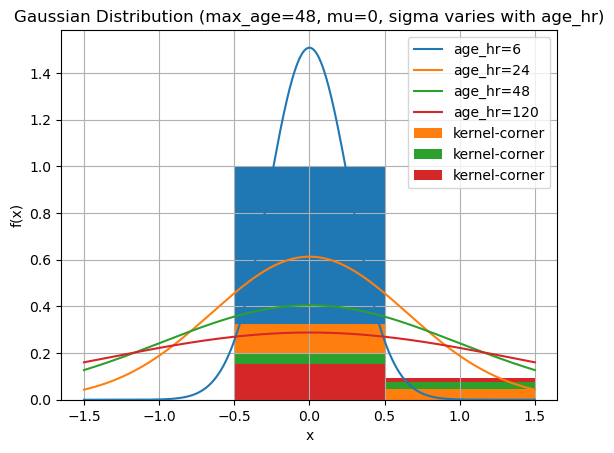

In [15]:
# plot a gaussian distribution

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf
def gaussian(x, mu, age_hr, max_age=48,kernel_size=3):
    min_sigma = 0.1
    # autoselecte a max_sigma depending on kernel_size
    max_sigma = kernel_size / 2.0
    # print(f"Using max_sigma={max_sigma} for kernel_size={kernel_size}")
    sigma = min_sigma + (max_sigma - min_sigma) * (1 - np.exp(-1* age_hr / max_age))
    return sigma, (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
def gaussian_cdf(mu, sigma, x):
    return 0.5 * (1 + erf((x - mu) / (sigma * np.sqrt(2))))

def gaussian_integral(x, sigma):
    return gaussian_cdf(0, sigma, x+0.5) - gaussian_cdf(0, sigma, x-0.5)

def gaussian_2d_area(mu, sigma, x1, x2, y1, y2):
    return (gaussian_cdf(mu, sigma, x2) - gaussian_cdf(mu, sigma, x1)) * (gaussian_cdf(mu, sigma, y2) - gaussian_cdf(mu, sigma, y1))

def gaussian_2d_area_kernel(mu, sigma, kernel_size):
    area_sum = 0
    kernel = np.zeros((kernel_size, kernel_size))
    max_val = gaussian_2d_area(mu, sigma, -0.5, 0.5, -0.5, 0.5)
    for x in range(-int(kernel_size/2), int(kernel_size/2)+1):
        for y in range(-int(kernel_size/2), int(kernel_size/2)+1):
            val = gaussian_2d_area(mu, sigma, x-0.5, x+0.5, y-0.5, y+0.5)
            if (max_val < 10*val):
                kernel[x+int(kernel_size/2), y+int(kernel_size/2)] = val
                area_sum += gaussian_2d_area(mu, sigma, x-0.5, x+0.5, y-0.5, y+0.5)
    kernel /= area_sum
    return kernel

kernel_size = 3

x = np.linspace(-1*(kernel_size/2), kernel_size/2, 1000)
mu = 0

age_hr_list = [6, 24, 48, 120]
max_age = 48
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color'][:len(age_hr_list)]
colors = [default_colors[i%len(age_hr_list)] for i in range(len(age_hr_list))]
fig, ax = plt.subplots()
for idx, age_hr in enumerate(age_hr_list):
    sigma, y = gaussian(x, mu, age_hr, max_age, kernel_size)
    print(idx, age_hr, sigma)
    ax.plot(x, y, label=f'age_hr={age_hr}', color=colors[idx], zorder=5)
    # plot also the integral under the curve between -.5 and .5, and so on as barcharts
    # the bars should be centered at the middle of the interval, and the width should be the size of the interval
    kernel = gaussian_2d_area_kernel(mu, sigma, kernel_size)
    for interval in range(int(kernel_size/2) + 1):
        integral = kernel[interval+int(kernel_size/2), interval+int(kernel_size/2)]
        print (f"Interval: {interval}, Integral: {integral}")
        if (integral > 0.):
            if (interval != int(kernel_size/2)):
                ax.bar(interval, integral, width=1, color=colors[idx])
            else:
                ax.bar(interval, integral, width=1, color=colors[idx], zorder=-idx, label='kernel-corner')



ax.set_title(f'Gaussian Distribution (max_age=48, mu=0, sigma varies with age_hr)')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.grid()
ax.legend( loc='upper right')
plt.show()

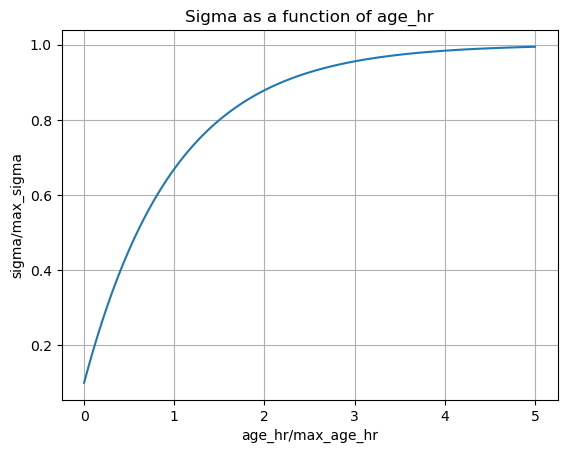

In [54]:
# plot a curve for the age_hr to sigma formula

age_hr_values = np.linspace(0, 5, 100)
# a typical formula for sigma as a function of age_hr
# for gaussian atmospheric transport models
min_sigma = 0.1
sigma_values = min_sigma + (1 - min_sigma) * (1-np.exp(age_hr_values / -1))
# why should sigma increase faster with age_hr

plt.plot(age_hr_values, sigma_values)
plt.title('Sigma as a function of age_hr')
plt.xlabel('age_hr/max_age_hr')
plt.ylabel('sigma/max_sigma')
plt.grid()
plt.show()


## Smoothing vs diffusion

SNAP horizontal diffusion is l = a * u ^ b, with u = horizontal wind-speed, and a = 0.5, b = 0.875 (a = 0.25 above ABL).
Valid at 15min.

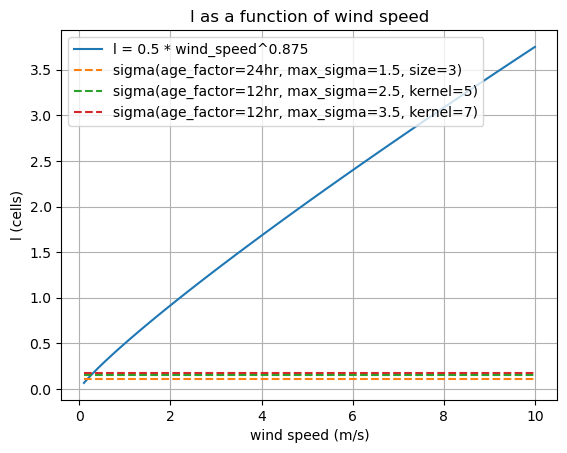

In [55]:
# plot l depending on wind-speed 0.1m/s to 20m/s
wind_speeds = np.linspace(0.1, 10, 100)
a = 0.5
b = 0.875
# a typical formula for l as a function of wind speed
l = a * wind_speeds**b
sigma24_3 = 0.1 + (1.5 - 0.1) * (1-np.exp(-1. * 0.25 / 24))
sigma12_5 = 0.1 + (2.5 - 0.1) * (1-np.exp(-1. * 0.25 / 12))
sigma12_7 = 0.1 + (3.5 - 0.1) * (1-np.exp(-1. * 0.25 / 12))
plt.plot(wind_speeds, l, label=f'l = {a} * wind_speed^{b}')
plt.plot(wind_speeds, np.full_like(wind_speeds, sigma24_3), label=f'sigma(age_factor=24hr, max_sigma=1.5, size=3)', linestyle='--')
plt.plot(wind_speeds, np.full_like(wind_speeds, sigma12_5), label=f'sigma(age_factor=12hr, max_sigma=2.5, kernel=5)', linestyle='--')
plt.plot(wind_speeds, np.full_like(wind_speeds, sigma12_7), label=f'sigma(age_factor=12hr, max_sigma=3.5, kernel=7)', linestyle='--')
plt.title('l as a function of wind speed')
plt.xlabel('wind speed (m/s)')
plt.ylabel('l (cells)')
plt.legend()
plt.grid()
plt.show()